In [1]:
import pandas as pd

import matplotlib.pyplot as plt 
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn import svm
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report

# Step 1: Explore and understand the data

In [2]:
data = pd.read_csv("BankChurnersData.csv")

In [3]:
#CLIENTNUM	Unique identifier for each customer. (Integer)
#Attrition_Flag	Flag indicating whether or not the customer has churned out. (Boolean)
#Customer_Age	Age of customer. (Integer)
#Gender	Gender of customer. (String)
#Dependent_count	Number of dependents that customer has. (Integer)
#Education_Level	Education level of customer. (String)
#Marital_Status	Marital status of customer. (String)
#Income_Category	Income category of customer. (String)
#Card_Category	Type of card held by customer. (String)
#Months_on_book	How long customer has been on the books. (Integer)
#Total_Relationship_Count	Total number of relationships customer has with the credit card provider. (Integer)
#Months_Inactive_12_mon	Number of months customer has been inactive in the last twelve months. (Integer)
#Contacts_Count_12_mon	Number of contacts customer has had in the last twelve months. (Integer)
#Credit_Limit	Credit limit of customer. (Integer)
#Total_Revolving_Bal	Total revolving balance of customer. (Integer)
#Avg_Open_To_Buy	Average open to buy ratio of customer. (Integer)
#Total_Amt_Chng_Q4_Q1	Total amount changed from quarter 4 to quarter 1. (Integer)
#Total_Trans_Amt	Total transaction amount. (Integer)
#Total_Trans_Ct	Total transaction count. (Integer)
#Total_Ct_Chng_Q4_Q1	Total count changed from quarter 4 to quarter 1. (Integer)
#Avg_Utilization_Ratio	Average utilization ratio of customer. (Integer)


In [4]:
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [5]:
data.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [6]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [7]:
desc = data.describe(include = 'all')

In [8]:
desc.head(10)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127,10127.000000,10127,10127.000000,10127,10127,10127,10127,10127.000000,...,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
unique,NaN,2,NaN,2,NaN,7,4,6,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Existing Customer,NaN,F,NaN,Graduate,Married,Less than $40K,Blue,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,8500,NaN,5358,NaN,3128,4687,3561,9436,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7.391776e+08,NaN,46.325960,NaN,2.346203,NaN,NaN,NaN,NaN,35.928409,...,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,NaN,8.016814,NaN,1.298908,NaN,NaN,NaN,NaN,7.986416,...,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,NaN,26.000000,NaN,0.000000,NaN,NaN,NaN,NaN,13.000000,...,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,NaN,41.000000,NaN,1.000000,NaN,NaN,NaN,NaN,31.000000,...,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,NaN,46.000000,NaN,2.000000,NaN,NaN,NaN,NaN,36.000000,...,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,NaN,52.000000,NaN,3.000000,NaN,NaN,NaN,NaN,40.000000,...,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000


# Step 2: Univariate data analysis

In [9]:
numerical_features = [z for z in data.columns if (data[z].dtype!=object)]

In [10]:
numerical_features.remove('CLIENTNUM')
data.drop('CLIENTNUM',axis=1, inplace=True)
numerical_features

['Customer_Age',
 'Dependent_count',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

In [11]:
categorical_features = [z for z in data.columns if (data[z].dtype==object)]

In [12]:
categorical_features.remove('Attrition_Flag')
categorical_features

['Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

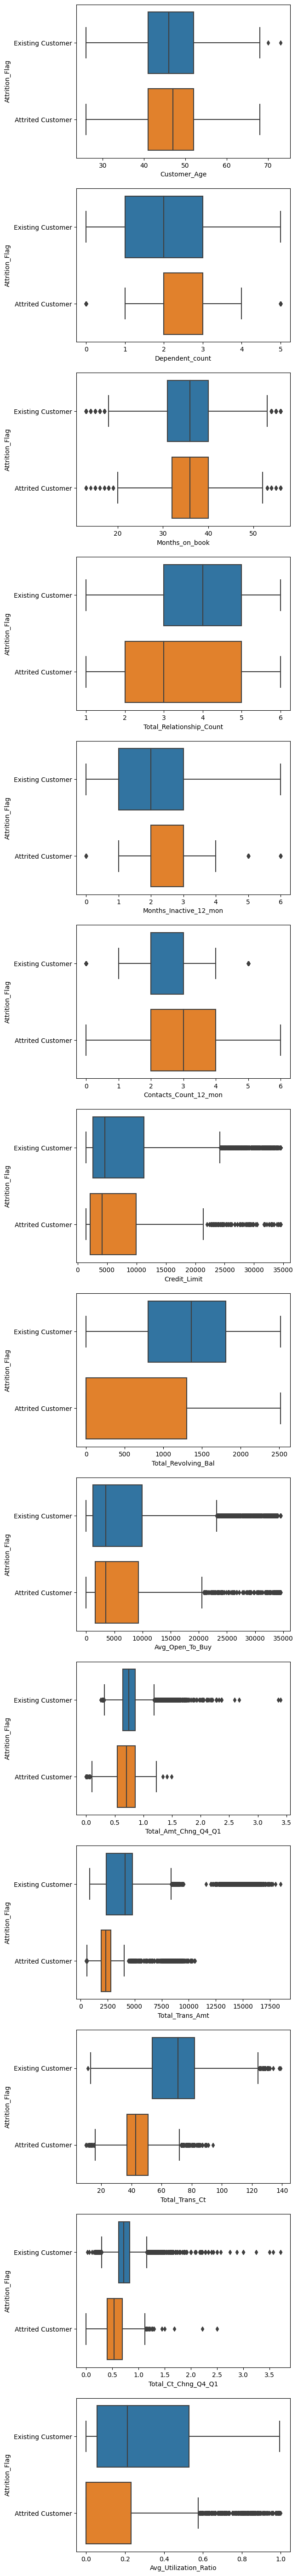

In [13]:

plt.figure(figsize=(6, 72
                   ))


for z in range(len(numerical_features)):
    plt.subplot(14,1,z+1)
    sns.boxplot(x = numerical_features[z], y = 'Attrition_Flag', data = data)
plt.show()

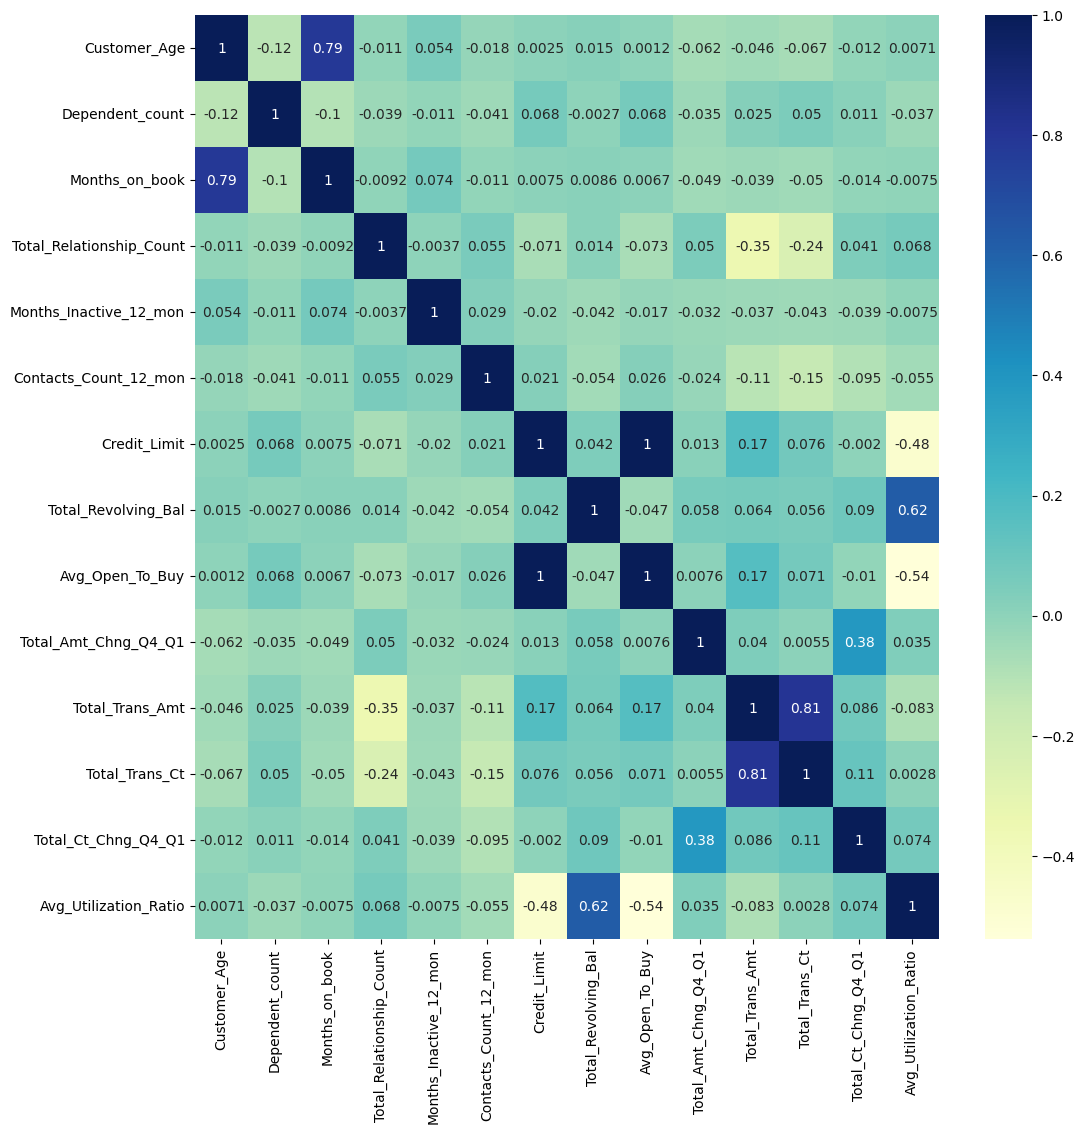

In [14]:
#Correlation of output with numerical variables

plt.figure(figsize=(12, 12))
# plotting correlation heatmap
dataplot = sns.heatmap(data[numerical_features].corr(), cmap="YlGnBu", annot=True)
  
# displaying heatmap
plt.show()

In [15]:
numerical_features.remove('Avg_Open_To_Buy')
data.drop('Avg_Open_To_Buy',axis=1,inplace=True)

In [16]:
# Trying to create new feature from the data
data['Average_transaction_value'] = data['Total_Trans_Amt']/data['Total_Trans_Ct']
numerical_features.append('Average_transaction_value')
numerical_features.remove('Total_Trans_Amt')
data[['Total_Trans_Amt','Total_Trans_Ct','Average_transaction_value']].head(10)




,Total_Trans_Amt,Total_Trans_Ct,Average_transaction_value
0,1144,42,27.238095
1,1291,33,39.121212
2,1887,20,94.350000
3,1171,20,58.550000
4,816,28,29.142857
5,1088,24,45.333333
6,1330,31,42.903226
7,1538,36,42.722222
8,1350,24,56.250000
9,1441,32,45.031250


In [17]:
data.drop(columns= ['Total_Trans_Amt'],inplace=True)


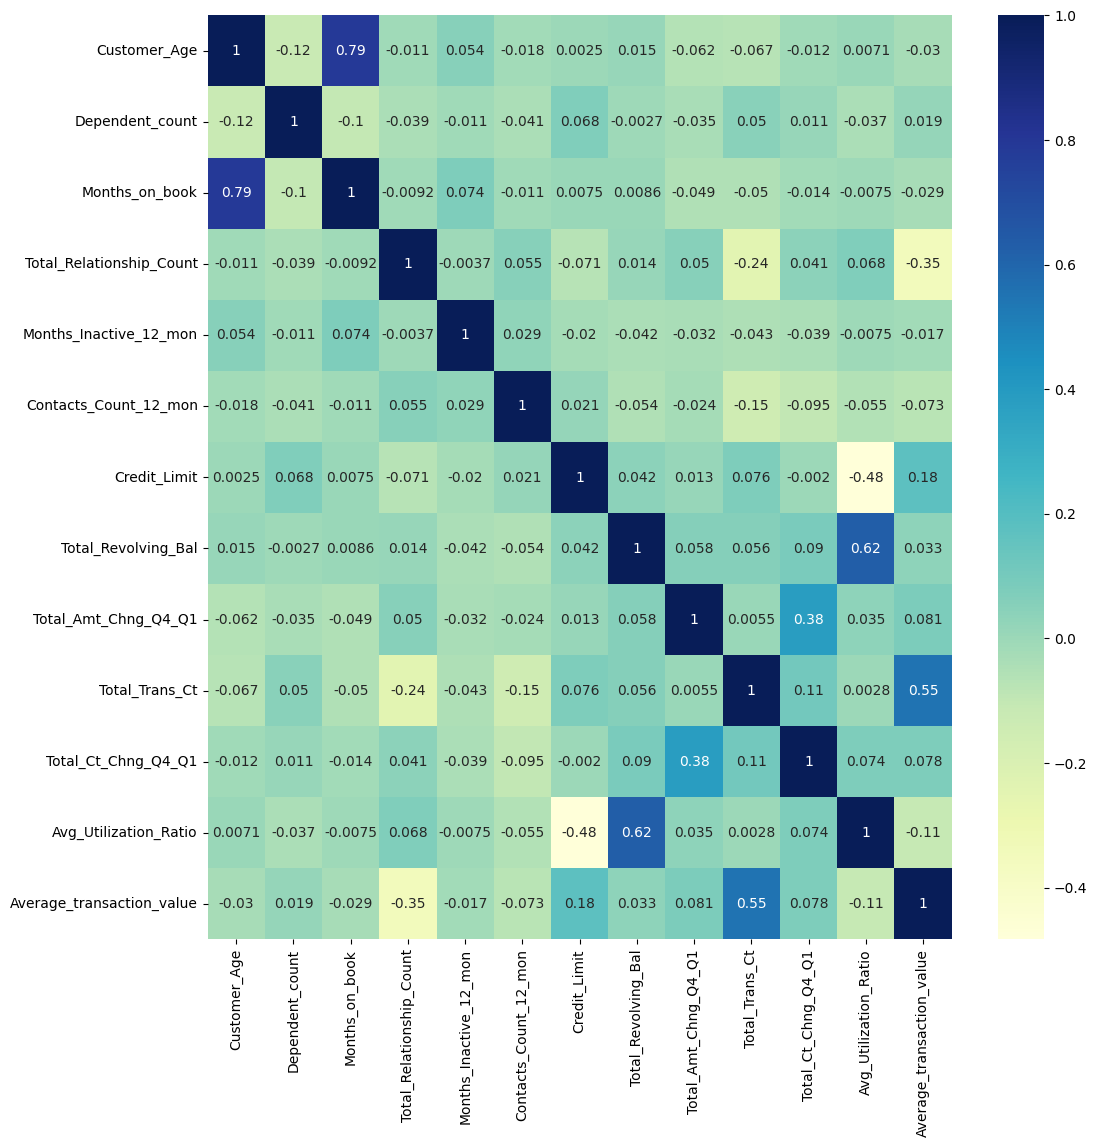

In [18]:
#Correlation of output with numerical variables

plt.figure(figsize=(12, 12))
# plotting correlation heatmap
dataplot = sns.heatmap(data[numerical_features].corr(), cmap="YlGnBu", annot=True)
  
# displaying heatmap
plt.show()

# Step 3: Create features and scale the data

In [19]:
#Create dummy features for categorical variables

data = pd.get_dummies(data=data, columns=categorical_features,drop_first=True)
data.columns

Index(['Attrition_Flag', 'Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
       'Avg_Utilization_Ratio', 'Average_transaction_value', 'Gender_M',
       'Education_Level_Doctorate', 'Education_Level_Graduate',
       'Education_Level_High School', 'Education_Level_Post-Graduate',
       'Education_Level_Uneducated', 'Education_Level_Unknown',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Unknown', 'Income_Category_$40K - $60K',
       'Income_Category_$60K - $80K', 'Income_Category_$80K - $120K',
       'Income_Category_Less than $40K', 'Income_Category_Unknown',
       'Card_Category_Gold', 'Card_Category_Platinum', 'Card_Category_Silver'],
      dtype='object')

In [20]:
def train_test_split_and_scale(data):
    y = data['Attrition_Flag']
    x = data.drop('Attrition_Flag',axis=1)
    features = list(x.columns)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state = 0)
    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)
    return x_train, x_test, y_train, y_test,features


In [21]:
x_train, x_test, y_train, y_test,features = train_test_split_and_scale(data)

In [22]:
Counter(y_train)

Counter({'Existing Customer': 6783, 'Attrited Customer': 1318})

In [23]:
Counter(y_test)

Counter({'Existing Customer': 1717, 'Attrited Customer': 309})

In [24]:
# fetaures in the data
len(x_test[0])

31

# Step 4: Train and evaluate the model

In [25]:
# C: Inverse regularization parameter ( high value of C - low regularization and vice versa)
# kernel: type of kernel for the model
# gamma: applicable only for RBF, polynomial and sigmoid kernel
# if gamma='scale' (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,
#if ‘auto’, uses 1 / n_features
#if float, must be non-negative.

def fit_and_evaluate_model(x_train, x_test, y_train, y_test, kernel='linear',C=1.0,gamma='scale'):
    model = svm.SVC(kernel=kernel,C=C,gamma=gamma)
    model = model.fit(x_train, y_train)
    svm_predict = model.predict(x_test)
    svm_conf_matrix = confusion_matrix(y_test, svm_predict)
    svm_acc_score = accuracy_score(y_test, svm_predict)
    print("confussion matrix")
    print(svm_conf_matrix)
    print("\n")
    print("Accuracy of SVM Classification:",svm_acc_score*100,'\n')
    print(classification_report(y_test,svm_predict))
    return model


In [26]:
print("Dimesion of features: ", len(x_train[0]))

Dimesion of features:  31


In [27]:


model = fit_and_evaluate_model(x_train, x_test, y_train, y_test,kernel='linear',C=1.0)
# get support vectors
print("Support Vectors")
print(model.support_vectors_)
print("Dimesion of support vector: ", len(model.support_vectors_[0]))
print("")

# get indices of support vectors
print("Indices of Support Vectors")
print(model.support_)
print("")

# get number of support vectors for each class
print("Number of Support Vectors for each class")
print(model.n_support_)
print("")

confussion matrix
[[ 188  121]
 [  59 1658]]


Accuracy of SVM Classification: 91.11549851924975 

                   precision    recall  f1-score   support

Attrited Customer       0.76      0.61      0.68       309
Existing Customer       0.93      0.97      0.95      1717

         accuracy                           0.91      2026
        macro avg       0.85      0.79      0.81      2026
     weighted avg       0.91      0.91      0.91      2026

Support Vectors
[[0.10638298 0.         0.18604651 ... 0.         0.         0.        ]
 [0.61702128 0.2        0.76744186 ... 0.         0.         0.        ]
 [0.36170213 0.4        0.53488372 ... 0.         0.         0.        ]
 ...
 [0.27659574 0.2        0.37209302 ... 0.         0.         0.        ]
 [0.40425532 0.6        0.62790698 ... 0.         0.         0.        ]
 [0.57446809 0.2        0.62790698 ... 0.         0.         0.        ]]
Dimesion of support vector:  31

Indices of Support Vectors
[  20   23   50 ... 8071

In [28]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test,kernel='rbf',C=1.0,gamma=0.1)
# get support vectors
print("Support Vectors")
print(model.support_vectors_)
print("Dimesion of support vector: ", len(model.support_vectors_[0]))
print("")

# get indices of support vectors
print("Indices of Support Vectors")
print(model.support_)
print("")

# get number of support vectors for each class
print("Number of Support Vectors for each class")
print(model.n_support_)
print("")

confussion matrix
[[ 177  132]
 [  42 1675]]


Accuracy of SVM Classification: 91.4116485686081 

                   precision    recall  f1-score   support

Attrited Customer       0.81      0.57      0.67       309
Existing Customer       0.93      0.98      0.95      1717

         accuracy                           0.91      2026
        macro avg       0.87      0.77      0.81      2026
     weighted avg       0.91      0.91      0.91      2026

Support Vectors
[[0.27659574 0.6        0.53488372 ... 0.         0.         0.        ]
 [0.10638298 0.         0.18604651 ... 0.         0.         0.        ]
 [0.61702128 0.2        0.76744186 ... 0.         0.         0.        ]
 ...
 [0.34042553 0.6        0.53488372 ... 0.         0.         0.        ]
 [0.40425532 0.6        0.62790698 ... 0.         0.         0.        ]
 [0.57446809 0.2        0.62790698 ... 0.         0.         0.        ]]
Dimesion of support vector:  31

Indices of Support Vectors
[   5   20   23 ... 8085 

# Step 5: Cross validation for model tuning

In [29]:
# cross validation is the technique of dividing training data into N sets
# Every time N-1 sets is used for training the model and 1 set for evaluating the model
# This is used for finding best possible value of hyperparameters on the given dataset

# set 1, set 2, set 3, set 4: set 5
# set 1, set 2, set 3, set 5: set 4
# set 1, set 2, set 4, set 5: set 3
# set 1, set 3, set 4, set 5: set 2
# set 2, set 3, set 4, set 5: set 1

In [30]:
param_grid = [
  {'C': [0.1,1, 10,100], 'kernel': ['linear']},
  {'C': [0.1,1, 10,100], 'gamma': [0.1, 0.001, 0.0001], 'kernel': ['rbf']},
 ]

#
#Low values of gamma indicate a large similarity radius which results in more points being grouped together. 
#For high values of gamma, the points need to be very close to each other in order to be considered in the same group (or class).
#Therefore, models with very large gamma values tend to overfit
# very low values can underfit

# Read about RBF kernel
#https://towardsdatascience.com/radial-basis-function-rbf-kernel-the-go-to-kernel-acf0d22c798a

In [31]:
from sklearn.model_selection import GridSearchCV
model = svm.SVC()
search = GridSearchCV(estimator = model, param_grid = param_grid, cv=5, verbose=5,scoring = 'balanced_accuracy')
search.fit(x_train, y_train)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END ..............C=0.1, kernel=linear;, score=0.734 total time=   0.6s
[CV 2/5] END ..............C=0.1, kernel=linear;, score=0.760 total time=   0.6s
[CV 3/5] END ..............C=0.1, kernel=linear;, score=0.714 total time=   0.6s
[CV 4/5] END ..............C=0.1, kernel=linear;, score=0.755 total time=   0.6s
[CV 5/5] END ..............C=0.1, kernel=linear;, score=0.713 total time=   0.6s
[CV 1/5] END ................C=1, kernel=linear;, score=0.782 total time=   0.5s
[CV 2/5] END ................C=1, kernel=linear;, score=0.799 total time=   0.6s
[CV 3/5] END ................C=1, kernel=linear;, score=0.759 total time=   0.6s
[CV 4/5] END ................C=1, kernel=linear;, score=0.797 total time=   0.6s
[CV 5/5] END ................C=1, kernel=linear;, score=0.778 total time=   0.6s
[CV 1/5] END ...............C=10, kernel=linear;, score=0.784 total time=   0.9s
[CV 2/5] END ...............C=10, kernel=linear;

GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [0.1, 1, 10, 100], 'kernel': ['linear']},
                         {'C': [0.1, 1, 10, 100], 'gamma': [0.1, 0.001, 0.0001],
                          'kernel': ['rbf']}],
             scoring='balanced_accuracy', verbose=5)

In [32]:
results = pd.DataFrame(search.cv_results_)
results.sort_values('mean_test_score',inplace=True,ascending= False)
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
13,1.130615,0.029584,0.241075,0.013786,100,rbf,0.1,"{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}",0.806281,0.834997,0.800969,0.844043,0.795639,0.816386,0.019399,1
10,0.765892,0.019359,0.271801,0.002891,10,rbf,0.1,"{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}",0.801918,0.811094,0.791286,0.827953,0.798807,0.806212,0.012590,2
3,2.779233,0.032270,0.074784,0.006920,100,linear,NaN,"{'C': 100, 'kernel': 'linear'}",0.783450,0.808146,0.771170,0.811695,0.784074,0.791707,0.015608,3
2,0.893547,0.035619,0.073486,0.008984,10,linear,NaN,"{'C': 10, 'kernel': 'linear'}",0.783819,0.806613,0.771170,0.810170,0.782180,0.790790,0.015058,4
1,0.588087,0.028495,0.085426,0.004729,1,linear,NaN,"{'C': 1, 'kernel': 'linear'}",0.781505,0.798581,0.758967,0.797281,0.777605,0.782788,0.014529,5
7,0.823830,0.023655,0.341034,0.014998,1,rbf,0.1,"{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}",0.759728,0.772953,0.733339,0.775191,0.730156,0.754273,0.019163,6
14,0.785455,0.011156,0.324190,0.016552,100,rbf,0.001,"{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}",0.760568,0.770315,0.720517,0.766140,0.744938,0.752496,0.018158,7
0,0.623189,0.010067,0.093747,0.000016,0.1,linear,NaN,"{'C': 0.1, 'kernel': 'linear'}",0.734370,0.759896,0.714386,0.755095,0.712691,0.735288,0.019729,8
11,1.029005,0.042256,0.393136,0.015786,10,rbf,0.001,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}",0.501894,0.505703,0.501901,0.505682,0.507576,0.504551,0.002273,9
15,1.038059,0.030046,0.397479,0.011456,100,rbf,0.0001,"{'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}",0.501894,0.505703,0.501901,0.505682,0.507576,0.504551,0.002273,9


In [33]:
results_save = pd.DataFrame(search.cv_results_)
results_save.to_csv("results_save.csv", index =False)

In [34]:
search.best_params_

{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}

# Step 6: Final results and evaluation

In [35]:
model = fit_and_evaluate_model(x_train, x_test, y_train, y_test,kernel='rbf',C=100,gamma=0.1)
# get support vectors
print("Support Vectors")
print(model.support_vectors_)
print("Dimesion of support vector: ", len(model.support_vectors_[0]))
print("")

# get indices of support vectors
print("Indices of Support Vectors")
print(model.support_)
print("")

# get number of support vectors for each class
print("Number of Support Vectors for each class")
print(model.n_support_)
print("")

confussion matrix
[[ 210   99]
 [  73 1644]]


Accuracy of SVM Classification: 91.51036525172755 

                   precision    recall  f1-score   support

Attrited Customer       0.74      0.68      0.71       309
Existing Customer       0.94      0.96      0.95      1717

         accuracy                           0.92      2026
        macro avg       0.84      0.82      0.83      2026
     weighted avg       0.91      0.92      0.91      2026

Support Vectors
[[0.10638298 0.         0.18604651 ... 0.         0.         0.        ]
 [0.61702128 0.2        0.76744186 ... 0.         0.         0.        ]
 [0.36170213 0.4        0.53488372 ... 0.         0.         0.        ]
 ...
 [0.27659574 0.2        0.37209302 ... 0.         0.         0.        ]
 [0.34042553 0.6        0.53488372 ... 0.         0.         0.        ]
 [0.40425532 0.6        0.62790698 ... 0.         0.         0.        ]]
Dimesion of support vector:  31

Indices of Support Vectors
[  20   23   50 ... 8071